# Practice Session 07: Connected components

*Introduction to Network Science* (2025/26), UPF

***Version 2***

Author: <font color="blue">Javier Algarra Pérez</font>

E-mail: <font color="blue">jalgarra@estudiant.upf.edu</font>

Date: <font color="blue">27/11/2025</font>

In [65]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import statistics

# 1. The Star Wars graph

In [ ]:
# LEAVE AS-IS

INPUT_GRAPH_FILENAME = "starwars.graphml"

# Read the graph in GraphML format
g_in = nx.read_graphml(INPUT_GRAPH_FILENAME)

# Re-label the nodes so they use the 'name' as label
g_relabeled = nx.relabel.relabel_nodes(g_in, dict(g_in.nodes(data='name')))

# Convert the graph to undirected
g = g_relabeled.to_undirected()

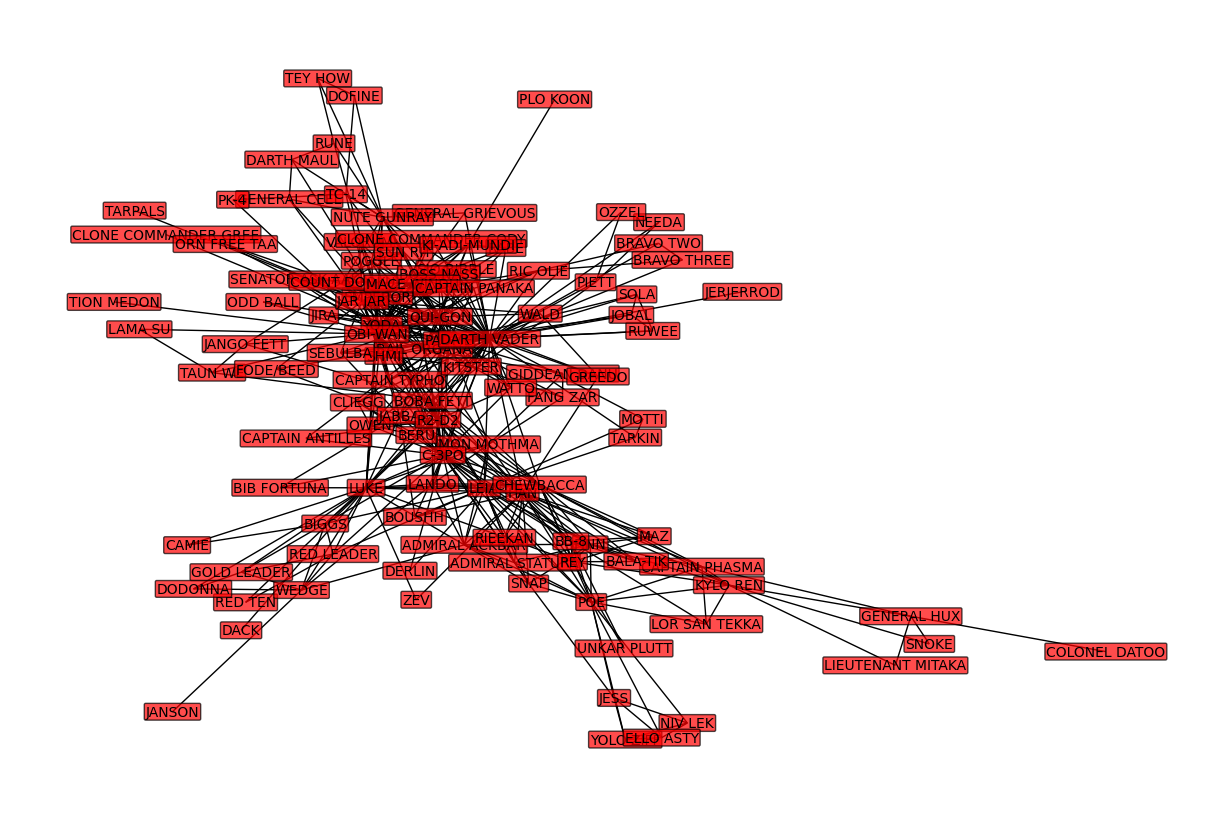

In [67]:
# LEAVE AS-IS (or modify slightly if you want) — we will reuse this function

def plot_graph(g):

    # Create a figure
    plt.figure(figsize=(12,8))

    # Layout the nodes using a spring model
    nx.draw_spring(
        g, 
        with_labels=True, font_size=10,     # Make labels, with label box defined below
        bbox=dict(facecolor="red", edgecolor='black', boxstyle='round,pad=0.1', alpha=0.7),
        node_size=0     # Hide nodes, leave only labels
    )

    # Display
    plt.show()

plot_graph(g)

In [68]:
# Is this a connected graph? Why or why not? With code.
is_connected = nx.is_connected(g)
print(f"Is the graph connected? {is_connected}")

Is the graph connected? True


Este grafo es un grafo conectado porque está en una sola pieza. No hay vértices aislados ni grupos de vértices separados del resto.  Existe un camino entre cualquier par de vértices del mismo.

In [69]:
# compute the maximum, mean and standard deviation of the degree of the nodes.
degrees = [d for n, d in g.degree()]
max_degree = max(degrees)
mean_degree = round(statistics.mean(degrees), 1)
stddev_degree = round(statistics.stdev(degrees),1)

print(f"Maximum degree: {max_degree}")
print(f"Mean degree: {mean_degree}")
print(f"Standard deviation of degree: {stddev_degree}")

Maximum degree: 52
Mean degree: 8.1
Standard deviation of degree: 8.7


1. Sí, tiee propiedades funcionales de una red libre de escala.

2. La clasificación se basa en la alta heterogeneidad de la distribución de grados, la cual es la propiedad clave de las redes *scale-free*:

* **Presencia de Hubs:** El nodo con grado **52** es un hub masivo que se encuentra muy alejado del grado medio k = 8.1. Esto crea una estructura **heterogénea** (no aleatoria).
* Prueba Cuantitativa de la Heterogeneidad: La desviación estándar observada ($\sigma_{obs} = 8.7$) es más de tres veces el valor esperado para una red aleatoria (ER) con la misma densidad ($\sigma_{ER} \approx 2.8$). Red con *hubs*.


3. Para una red aleatoria, el grado medio k es igual a la varianza ($\sigma^2$), siguiendo una distribución de Poisson.

El valor esperado de la desviación estándar sería:
$$\sigma_{ER} = \sqrt{\langle k \rangle} = \sqrt{8.1} \approx 2.8$$

La gran diferencia entre este valor esperado ($\mathbf{2.8}$) y el valor en la red de Star Wars ($\mathbf{8.7}$) es la prueba que su estructura es no aleatoria.

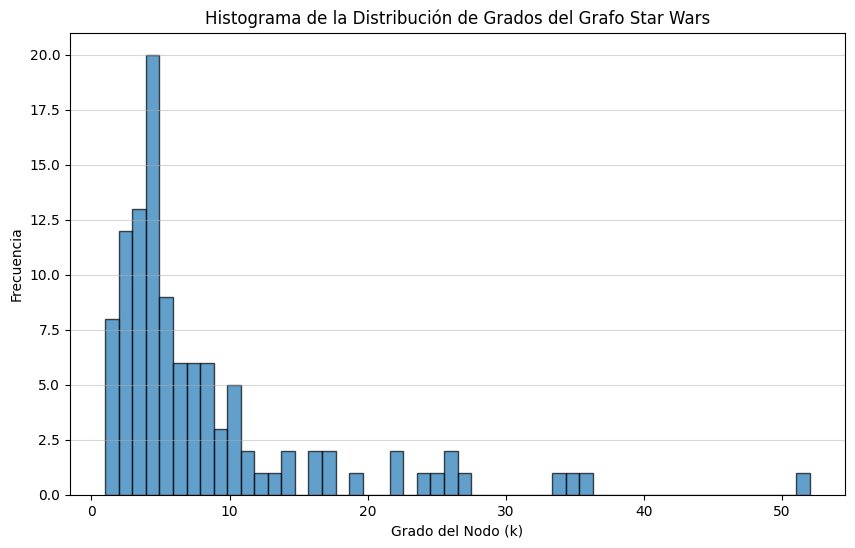

In [70]:
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=52, edgecolor='black', alpha=0.7) 

plt.title('Histograma de la Distribución de Grados del Grafo Star Wars')
plt.xlabel('Grado del Nodo (k)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.5)

plt.show()

# 2. Remove a fraction of edges

In [71]:
# LEAVE AS-IS

def remove_edges_uniformly_at_random(g_in, p):
    # Check input is within bounds
    if p < 0.0 or p > 1.0:
        raise ValueError

    # Create a copy of the input graph
    g_out = g_in.copy()

    # Decide how many edges should be in the output graph
    target_num_edges = int((1.0-p) * g_in.number_of_edges())

    # While there are more edges than desired
    while g_out.number_of_edges() > target_num_edges:

        # Remove one random edge
        edge = random.choice(list(g_out.edges()))

        if g_out.has_edge(edge[0], edge[1]):
            g_out.remove_edge(edge[0], edge[1])

    # Return the resulting graph
    return g_out

In [72]:
p_remove_10 = 0.1 
p_remove_50 = 0.5 
p_remove_90 = 0.9 

# Crear los grafos:
g90 = remove_edges_uniformly_at_random(g, p_remove_10)
g50 = remove_edges_uniformly_at_random(g, p_remove_50)
g10 = remove_edges_uniformly_at_random(g, p_remove_90)

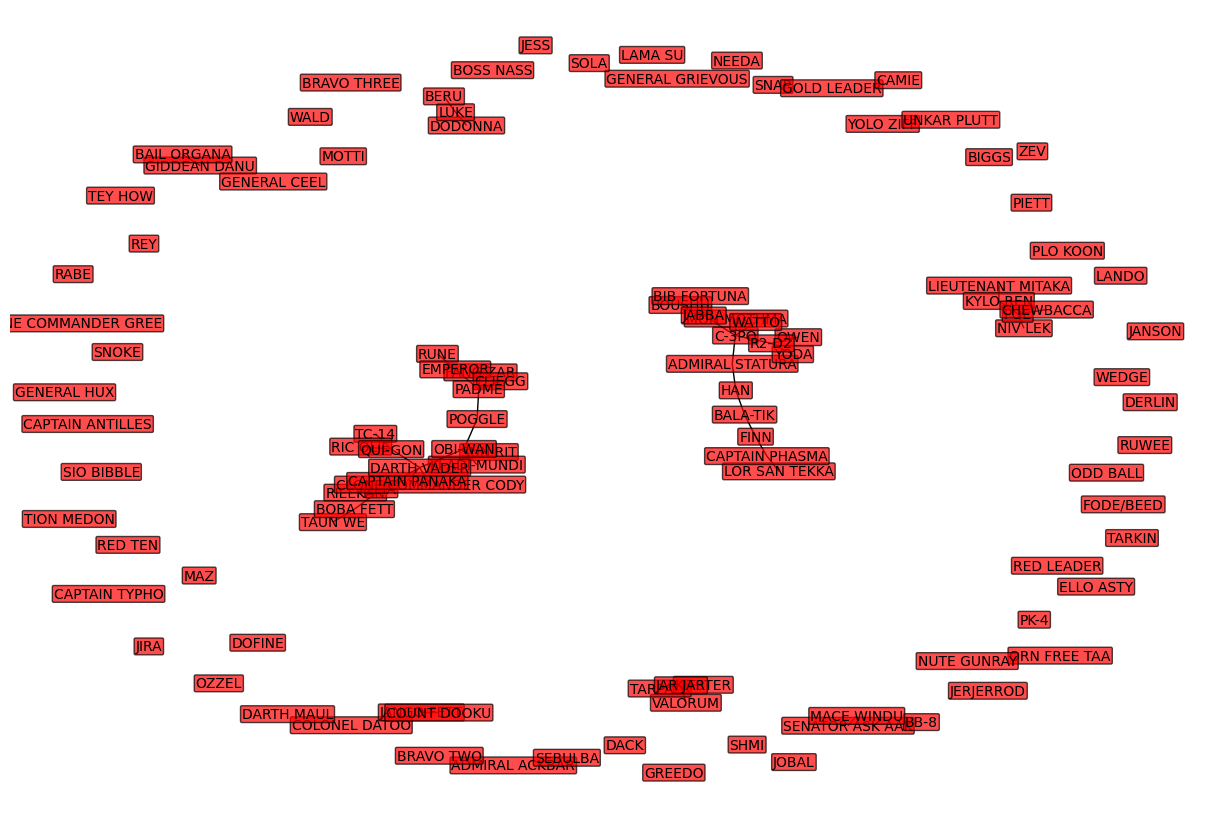

In [73]:
plot_graph(g10)

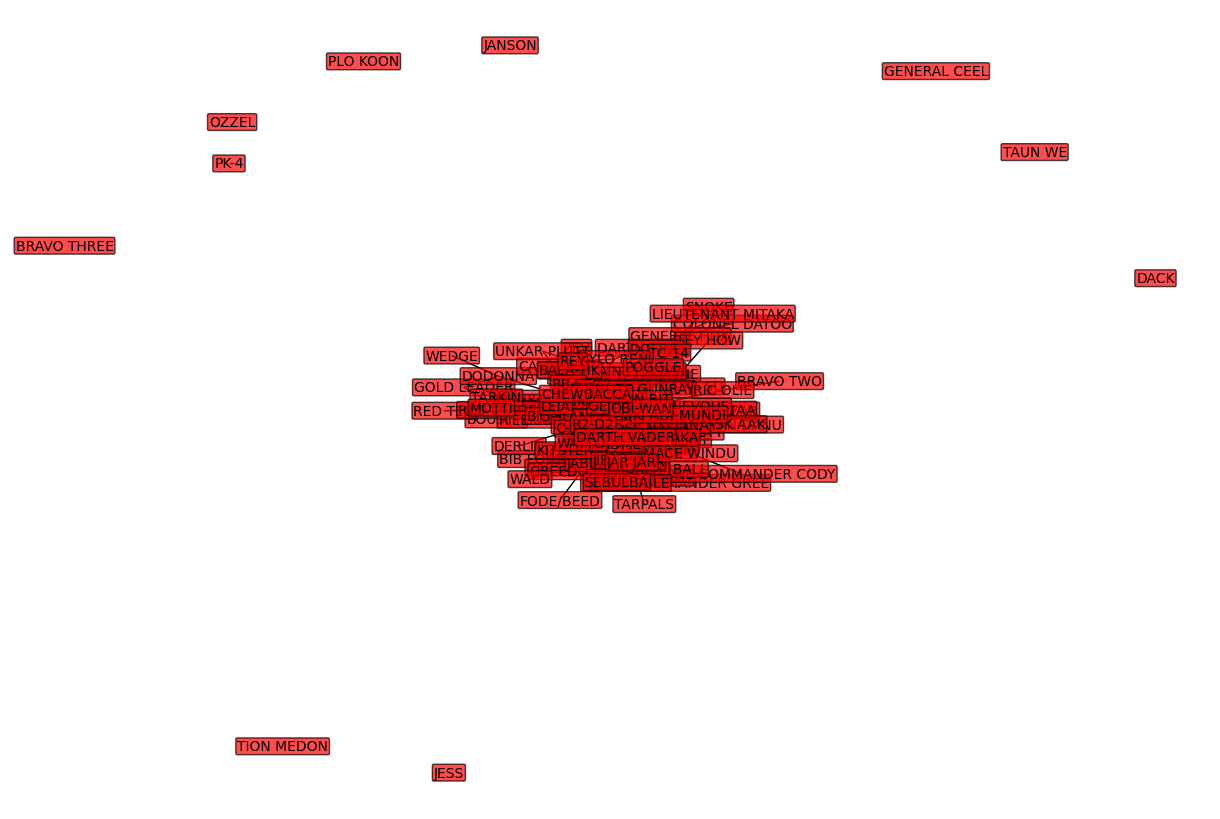

In [74]:
plot_graph(g50)

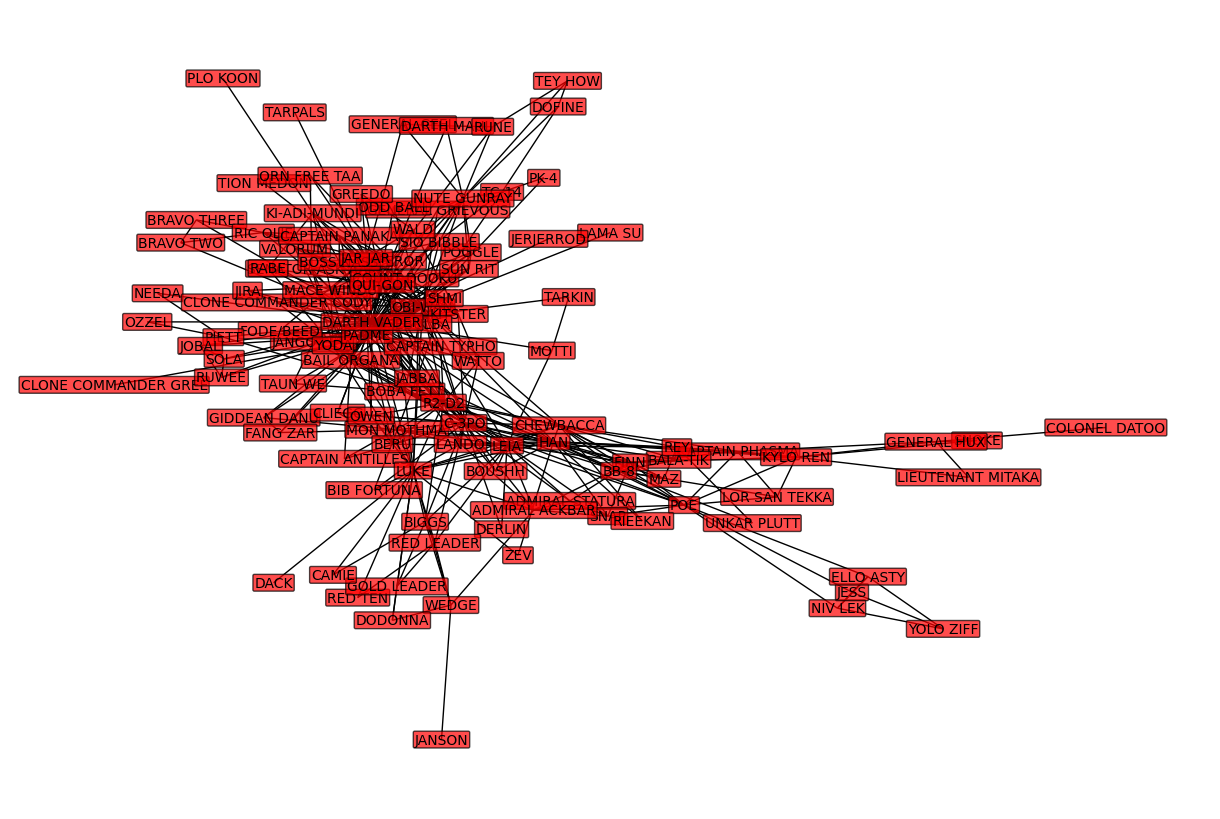

In [75]:
plot_graph(g90)

As we remove more edges...
1. El número de componentes conectados está aumentando.

2. El tamaño del componente conectado más grande está disminuyendo.

In [76]:
# Codigo para respaldar la respuesta anterior
connected_components = list(nx.connected_components(g))
num_components = len(connected_components)
print(f"Number of connected components in the original graph: {num_components}")

# g10
connected_components_g10 = list(nx.connected_components(g10))
num_components_g10 = len(connected_components_g10)
print(f"Number of connected components in g10: {num_components_g10}")
largest_component_g10 = max(connected_components_g10, key=len)
print(f"Size of the largest component in g10: {len(largest_component_g10)}")

# g50
connected_components_g50 = list(nx.connected_components(g50))
num_components_g50 = len(connected_components_g50)
print(f"Number of connected components in g50: {num_components_g50}")
largest_component_g50 = max(connected_components_g50, key=len)
print(f"Size of the largest component in g50: {len(largest_component_g50)}")

# g90
connected_components_g90 = list(nx.connected_components(g90))
num_components_g90 = len(connected_components_g90)
print(f"Number of connected components in g90: {num_components_g90}")
largest_component_g90 = max(connected_components_g90, key=len)
print(f"Size of the largest component in g90: {len(largest_component_g90)}")

Number of connected components in the original graph: 1
Number of connected components in g10: 66
Size of the largest component in g10: 19
Number of connected components in g50: 11
Size of the largest component in g50: 100
Number of connected components in g90: 1
Size of the largest component in g90: 110


In [77]:
# LEAVE AS-IS

def remove_edges_by_betweenness(g_in, p):
    # Check input is within bounds
    if p < 0.0 or p > 1.0:
        raise ValueError

    # Create a copy of the input graph
    g_out = g_in.copy()

    # Compute edge betweenness
    edge_betweenness = nx.edge_betweenness_centrality(g_out)
    edges_by_betweenness = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)

    # Decide how many edges should be in the output graph
    target_num_edges = int((1.0-p) * g_in.number_of_edges())

    # While there are more edges than desired
    while g_out.number_of_edges() > target_num_edges:
        edge_to_remove, betweenness = edges_by_betweenness.pop(0)
        g_out.remove_edge(*edge_to_remove)

    # Return the resulting graph
    return g_out

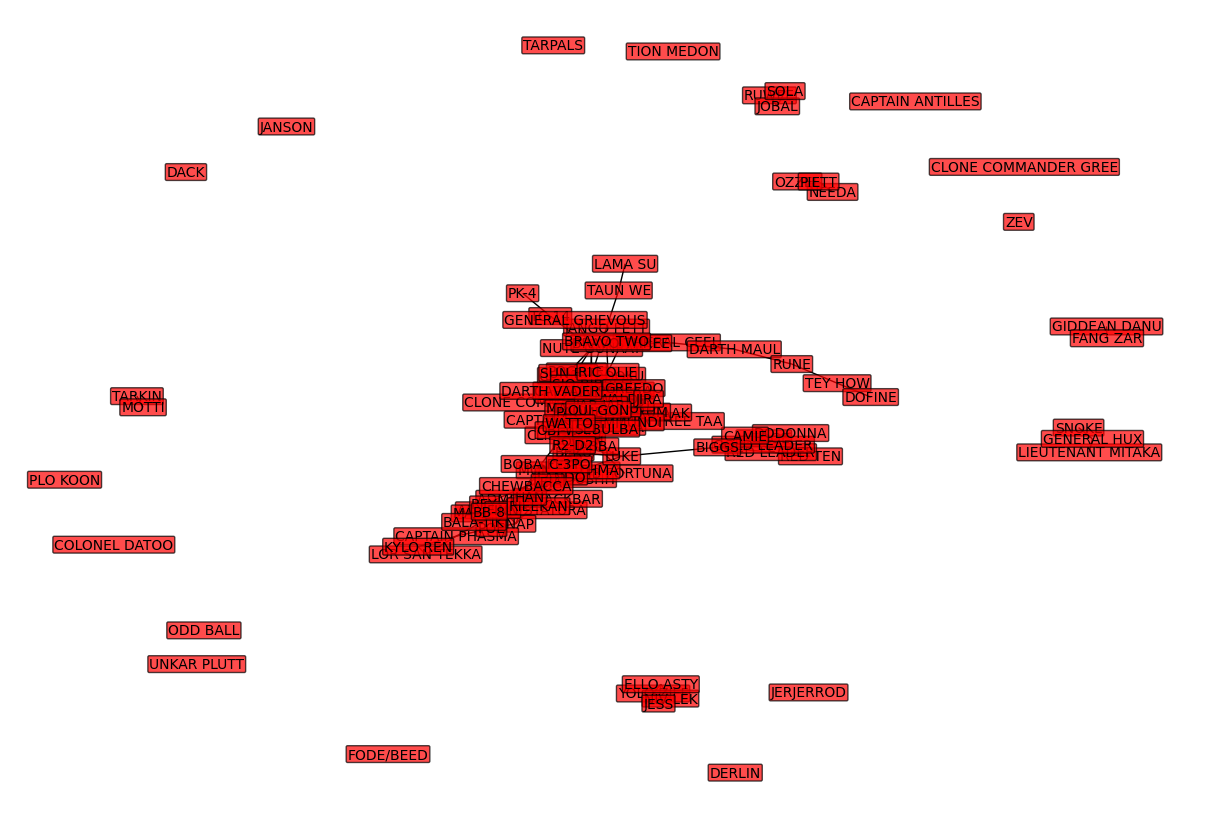

In [78]:
# LEAVE AS-IS

g50b = remove_edges_by_betweenness(g, 0.50)
plot_graph(g50b)

El grafo g50b (eliminación del 50% de las aristas por centralidad de betweenness) tiene un mayor número de componentes conectados (y componentes de menor tamaño) en comparación con el grafo g50 (eliminación del 50% de las aristas al azar). La red g50b aparece más fragmentada.

Porque la centralidad de Betweenness identifica y elimina las aristas que actúan como "puentes" de la conectividad. Al eliminar selectivamente estas aristas críticas, se rompen las vías que conectaban grandes subgrupos, en cambio el g50 utiliza l'aleatoridad para elegir las aristas eliminadas

# 3. Assigning connected components

In [79]:
def assign_component_recursive(g, node2componentid, starting_node, componentid):
    node2componentid[starting_node] = componentid

    for neighbor in g.neighbors(starting_node):
        if neighbor not in node2componentid:
            assign_component_recursive(g, node2componentid, neighbor, componentid)


def assign_components(g):
    # 1. Crear un diccionario
    node2componentid = {}

    # 2. Inicializar el ID
    componentid = 1

    for node in g.nodes():
        if node not in node2componentid:
            assign_component_recursive(g, node2componentid, node, componentid)
            componentid += 1

    return node2componentid

In [80]:
# LEAVE AS-IS

# Test on cycle graph
cycle_components = assign_components(nx.cycle_graph(10))
for componentid in cycle_components.values():
    assert componentid == 1, "All nodes in cycle graph should belong to the same component, with ID 1."

# Test on caveman graph
caveman_components = assign_components(nx.caveman_graph(3, 3))
for componentid in caveman_components.values():
    assert componentid in [1, 2, 3], "Nodes in caveman graph should belong to one of three components (1, 2, or 3)."
    assert len([n for n, c in caveman_components.items() if c == componentid]) == 3, "There should be exactly 3 nodes assigned to each component in the caveman graph."

In [81]:
# LEAVE AS-IS

# Get component assignments of nodes using the function just defined
components_g50b = assign_components(g50b)

# Print component assignments
for character in ['LUKE', 'KYLO REN', 'SNOKE', 'PLO KOON'] :
    print(f"Character {character:<8} belongs to component {components_g50b[character]}")

Character LUKE     belongs to component 3
Character KYLO REN belongs to component 3
Character SNOKE    belongs to component 4
Character PLO KOON belongs to component 12


# 4. Largest connected component

In [82]:
def extract_connected_component_sizes(g):
    # IDs de componente a cada nodo
    node2componentid = assign_components(g)
    
    component_sizes = {}

    for componentid in node2componentid.values():
        component_sizes[componentid] = component_sizes.get(componentid, 0) + 1
        
    return component_sizes


component_sizes_g50b = extract_connected_component_sizes(g50b)

print("Componentes Conectados (Tamaño > 1) en g50b:")

components_list = [
    (cid, size) 
    for cid, size in component_sizes_g50b.items() 
    if size > 1 
]

sorted_large_components = sorted(
    components_list, 
    key=lambda item: item[1], 
    reverse=True
)

for componentid, size in sorted_large_components:
    print(f"Component ID: {componentid} Tamaño: {size}")

Componentes Conectados (Tamaño > 1) en g50b:
Component ID: 3 Tamaño: 79
Component ID: 1 Tamaño: 4
Component ID: 4 Tamaño: 3
Component ID: 18 Tamaño: 3
Component ID: 21 Tamaño: 3
Component ID: 11 Tamaño: 2
Component ID: 19 Tamaño: 2


In [83]:
def size_largest_connected_component(g):
    if g.number_of_nodes() == 0:
        return 0
        
    component_sizes = extract_connected_component_sizes(g)
    
    return max(component_sizes.values()) if component_sizes else 0


In [84]:
num_nodes_g = g.number_of_nodes()

p_values = np.arange(0.0, 1.01, 0.05)

size_lcc_removing_uniformly_at_random = {}
size_lcc_removing_by_betweenness = {}

for p in p_values:
    g_removed_random = remove_edges_uniformly_at_random(g, p)
    lcc_size_random = size_largest_connected_component(g_removed_random)
    
    size_lcc_removing_uniformly_at_random[p] = lcc_size_random / num_nodes_g

    
    g_removed_betweenness = remove_edges_by_betweenness(g, p)
    lcc_size_betweenness = size_largest_connected_component(g_removed_betweenness)
    
    size_lcc_removing_by_betweenness[p] = lcc_size_betweenness / num_nodes_g



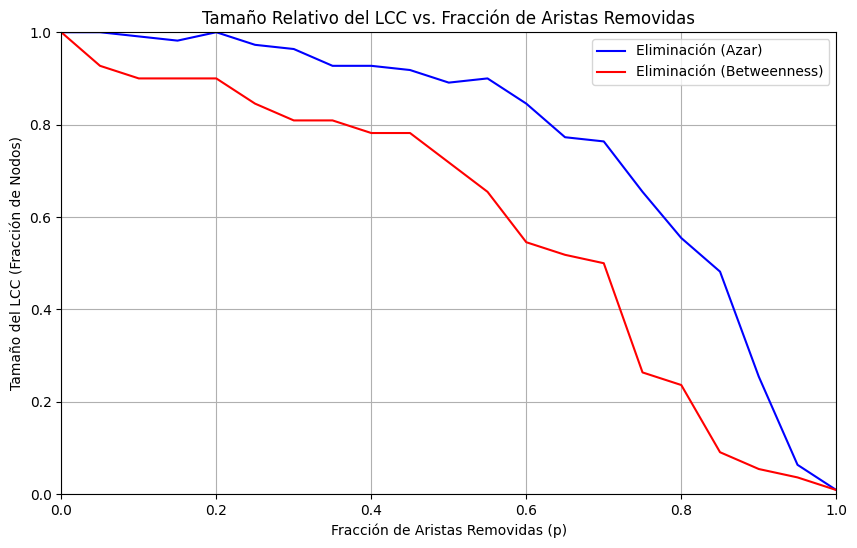

In [85]:
p_random = list(size_lcc_removing_uniformly_at_random.keys())
lcc_fraction_random = list(size_lcc_removing_uniformly_at_random.values())

p_betweenness = list(size_lcc_removing_by_betweenness.keys())
lcc_fraction_betweenness = list(size_lcc_removing_by_betweenness.values())

plt.figure(figsize=(10, 6))

plt.plot(
    p_random, 
    lcc_fraction_random, 
    label='Eliminación (Azar)', 
    color='blue'
)

plt.plot(
    p_betweenness, 
    lcc_fraction_betweenness, 
    label='Eliminación (Betweenness)', 
    color='red'
)

plt.title('Tamaño Relativo del LCC vs. Fracción de Aristas Removidas')
plt.xlabel('Fracción de Aristas Removidas (p)')
plt.ylabel('Tamaño del LCC (Fracción de Nodos)')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.grid(True)
plt.legend()

1. En la estrategia de eliminación por betweenness, al eliminar aproximadamente entre el 0% y el 5% de las aristas, la curva cae pronunciadamente desde el inicio. En cambio, bajo la estrategia de eliminación al azar, al eliminar alrededor de un 15% a 25% de las aristas, la curva se mantiene alta y desciende de manera gradual.
2. En el ataque por betweenness se eliminan primero las aristas más importantes, que actúan como puentes. Al quitarlas, incluso con un 0–5% de aristas eliminadas, la red se fragmenta rápido y la curva cae casi en vertical. En la al azar, las aristas se quitan sin considerar su importancia, eliminando un 15–25%, la red sigue teniendo una gran componente conexa.


In [86]:
def average_lcc_size_fraction_random(g, p_values, num_nodes, num_runs):
    all_lcc_sizes = {p: [] for p in p_values}
    
    for run in range(num_runs):
        for p in p_values:
            g_removed_random = remove_edges_uniformly_at_random(g, p)
            lcc_size = size_largest_connected_component(g_removed_random)
            all_lcc_sizes[p].append(lcc_size)
            
    avg_lcc_sizes_fraction = {}
    for p in p_values:
        avg_size = statistics.mean(all_lcc_sizes[p])
        avg_lcc_sizes_fraction[p] = avg_size / num_nodes
        
    return avg_lcc_sizes_fraction

In [87]:
num_nodes_g = g.number_of_nodes()
num_runs = 50 
p_values = np.arange(0.0, 1.01, 0.02) 

size_lcc_removing_uniformly_at_random_avg = average_lcc_size_fraction_random(
    g, 
    p_values, 
    num_nodes_g, 
    num_runs
)

size_lcc_removing_by_betweenness = {}
for p in p_values:
    g_removed_betweenness = remove_edges_by_betweenness(g, p)
    lcc_size_betweenness = size_largest_connected_component(g_removed_betweenness)
    size_lcc_removing_by_betweenness[p] = lcc_size_betweenness / num_nodes_g
    
print("Completado.")

Completado.


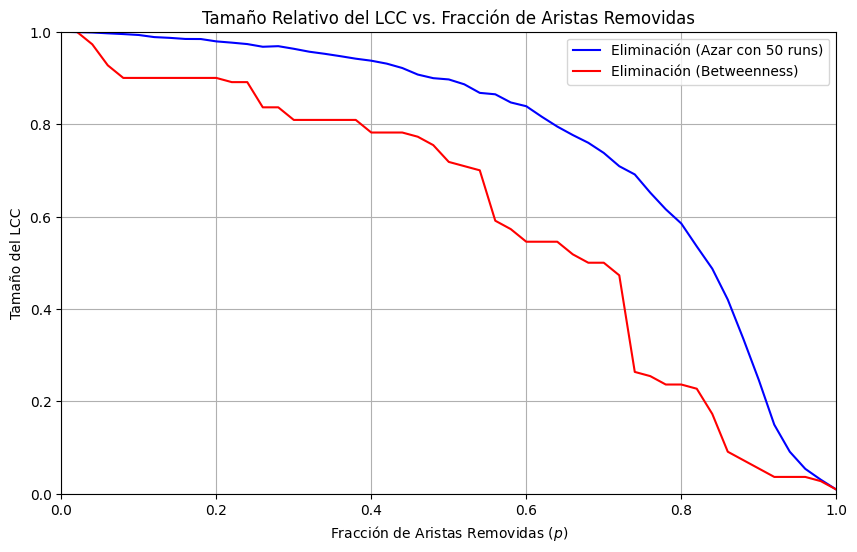

In [88]:
p_random_avg = list(size_lcc_removing_uniformly_at_random_avg.keys())
lcc_fraction_random_avg = list(size_lcc_removing_uniformly_at_random_avg.values())

p_betweenness = list(size_lcc_removing_by_betweenness.keys())
lcc_fraction_betweenness = list(size_lcc_removing_by_betweenness.values())

plt.figure(figsize=(10, 6))

plt.plot(
    p_random_avg, 
    lcc_fraction_random_avg, 
    label=f'Eliminación (Azar con {num_runs} runs)', 
    color='blue'
)

plt.plot(
    p_betweenness, 
    lcc_fraction_betweenness, 
    label='Eliminación (Betweenness)', 
    color='red'
)

plt.title('Tamaño Relativo del LCC vs. Fracción de Aristas Removidas')
plt.xlabel('Fracción de Aristas Removidas ($p$)')
plt.ylabel('Tamaño del LCC')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.grid(True)
plt.legend()

plt.show()

Gráfico Anterior (1 Run): La línea era  irregular y escalonada. 

Gráfico Actual (50 Runs): La línea de eliminación al azar es suave y continua. Al promediar 50 resultados, se eliminan estas fluctuaciones aleatorias, una estimación mucho más estable.

<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>